 # <center>TRABAJO FINAL — REDES NEURONALES</center>
## Predicción de Cancelaciones de Reservas Hoteleras

---

| Campo | Detalle |
|---|---|
| **Nombre completo** | Amira Roman|
| **Tema** | Clasificación con Redes Neuronales Artificiales |
| **Dataset** | Hotel Booking Demand (119,390 registros × 32 columnas) |
| **Fuente** | Kaggle / Antonio, Almeida & Nunes (2019) |
| **Fecha** | Junio 2025 |
| **Materia** | BIG DATA |
| **Docente** | Efrain Luna |


---
## 1.  INTRODUCCIÓN

### 1.1 Problema a Resolver

La industria hotelera enfrenta uno de sus mayores desafíos operativos en la gestión de cancelaciones de reservas. Una cancelación imprevista implica pérdida de ingresos, ineficiencia en la asignación de recursos (habitaciones, personal, insumos) y dificultades en la planificación de la demanda. Según datos del sector, las tasas de cancelación en hoteles oscilan entre el 30% y el 50% dependiendo del canal de distribución utilizado.

Este trabajo aborda la pregunta: **¿Es posible predecir si una reserva hotelera será cancelada antes de la fecha de llegada?**

### 1.2 Relevancia del Problema

Predecir cancelaciones con alta precisión permite a los hoteles:
- Implementar estrategias de **overbooking controlado** para maximizar la ocupación.
- Diseñar **políticas de depósito diferenciadas** según el perfil de riesgo del cliente.
- Optimizar la **gestión de inventario** de habitaciones.
- Reducir pérdidas económicas mediante intervenciones proactivas (descuentos de retención, recordatorios personalizados).

Las Redes Neuronales Artificiales (RNA) son especialmente adecuadas para este problema dado el volumen de datos (>100,000 registros), la combinación de variables categóricas y numéricas, y las relaciones no lineales entre predictores que serían difíciles de capturar con modelos lineales tradicionales.

### 1.3 Variable Objetivo

La variable objetivo es **`is_canceled`**: variable binaria (0 = No cancelada, 1 = Cancelada). Se trata de un problema de **clasificación binaria supervisada**.


---
## 2. INSTALACIÓN E IMPORTACIÓN DE LIBRERÍAS

In [2]:
# ============================================================
# INSTALACIÓN DE LIBRERÍAS ADICIONALES (si es necesario)
# ============================================================
!pip install scikit-learn matplotlib seaborn pandas numpy tensorflow -q

# ============================================================
# IMPORTACIONES PRINCIPALES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, roc_curve, auc, roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

# Configuración de visualizaciones
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

# Semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Todas las librerías importadas correctamente')
print(f'   TensorFlow versión: {tf.__version__}')
print(f'   Pandas versión:     {pd.__version__}')
print(f'   NumPy versión:      {np.__version__}')

Todas las librerías importadas correctamente
   TensorFlow versión: 2.20.0
   Pandas versión:     2.2.2
   NumPy versión:      2.0.2


---
## 3. DESCRIPCIÓN DEL DATASET

### 3.1 Carga del Dataset

In [4]:
# ============================================================
# CARGA DESDE URL DIRECTA DEL DATASET DE KAGGLE
# ============================================================
#  URL pública (TidyTuesday GitHub)
URL = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv'

print(' Cargando dataset...')
df = pd.read_csv(URL)
print(f' Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print()
print('Primeras 5 filas:')
df.head()

 Cargando dataset...
 Dataset cargado: 119,390 filas × 32 columnas

Primeras 5 filas:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### 3.2 Información General del Dataset

| Característica | Valor |
|---|---|
| **Nombre** | Hotel Booking Demand Dataset |
| **Fuente original** | Antonio, Almeida & Nunes (2019) — *Data in Brief*, Vol. 22 |
| **Limpieza** | Thomas Mock & Antoine Bichat para #TidyTuesday (Feb 2020) |
| **Filas** | 119,390 reservas |
| **Columnas** | 32 variables |
| **Período** | 2015 – 2017 |
| **Hoteles** | Resort Hotel y City Hotel (Portugal) |

**Variables categóricas (≥3):** `hotel`, `meal`, `country`, `market_segment`, `distribution_channel`, `reserved_room_type`, `assigned_room_type`, `deposit_type`, `customer_type`, `reservation_status`

**Variables numéricas (≥10):** `is_canceled`, `lead_time`, `arrival_date_year`, `arrival_date_week_number`, `arrival_date_day_of_month`, `stays_in_weekend_nights`, `stays_in_week_nights`, `adults`, `children`, `babies`, `is_repeated_guest`, `previous_cancellations`, `previous_bookings_not_canceled`, `booking_changes`, `days_in_waiting_list`, `adr`, `required_car_parking_spaces`, `total_of_special_requests`

In [6]:
# ============================================================
# INFORMACIÓN DETALLADA
# ============================================================
print('='*60)
print('INFORMACIÓN DEL DATASET')
print('='*60)
df.info()

print('\n' + '='*60)
print('TIPOS DE DATOS POR CATEGORÍA')
print('='*60)
numericas = df.select_dtypes(include=[np.number]).columns.tolist()
categoricas = df.select_dtypes(include=['object']).columns.tolist()
print(f'Variables numéricas  ({len(numericas)}): {numericas}')
print(f'\nVariables categóricas ({len(categoricas)}): {categoricas}')

print('\n' + '='*60)
print('DISTRIBUCIÓN DE LA VARIABLE OBJETIVO')
print('='*60)
target_counts = df['is_canceled'].value_counts()
print(f'No canceladas (0): {target_counts[0]:,} ({target_counts[0]/len(df)*100:.1f}%)')
print(f'Canceladas    (1): {target_counts[1]:,} ({target_counts[1]/len(df)*100:.1f}%)')

INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64

---
## 4. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

### 4.1 Estadísticas Descriptivas

In [7]:
# ============================================================
# ESTADÍSTICAS DESCRIPTIVAS
# ============================================================
print('ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS')
df[numericas].describe().round(2)

ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119386.0,119390.00,119390.00,119390.00,119390.00,119390.00,103050.00,6797.00,119390.00,119390.00,119390.00,119390.00
mean,0.37,104.01,2016.16,27.17,15.80,0.93,2.50,1.86,0.1,0.01,0.03,0.09,0.14,0.22,86.69,189.27,2.32,101.83,0.06,0.57
std,0.48,106.86,0.71,13.61,8.78,1.00,1.91,0.58,0.4,0.10,0.18,0.84,1.50,0.65,110.77,131.66,17.59,50.54,0.25,0.79
min,0.00,0.00,2015.00,1.00,1.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,1.00,6.00,0.00,-6.38,0.00,0.00
25%,0.00,18.00,2016.00,16.00,8.00,0.00,1.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,9.00,62.00,0.00,69.29,0.00,0.00
50%,0.00,69.00,2016.00,28.00,16.00,1.00,2.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,14.00,179.00,0.00,94.58,0.00,0.00
75%,1.00,160.00,2017.00,38.00,23.00,2.00,3.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,229.00,270.00,0.00,126.00,0.00,1.00
max,1.00,737.00,2017.00,53.00,31.00,19.00,50.00,55.00,10.0,10.00,1.00,26.00,72.00,21.00,535.00,543.00,391.00,5400.00,8.00,5.00


### 4.2 Valores Nulos

COLUMNAS CON VALORES NULOS:
           Nulos  Porcentaje (%)
children       4            0.00
country      488            0.41
agent      16340           13.69
company   112593           94.31


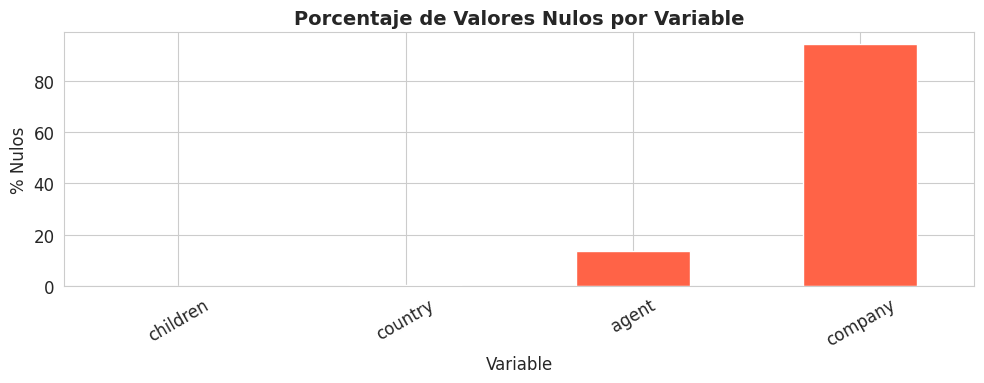

In [8]:
# ============================================================
# ANÁLISIS DE VALORES NULOS
# ============================================================
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
nulos_df = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
nulos_con_datos = nulos_df[nulos_df['Nulos'] > 0]

print('COLUMNAS CON VALORES NULOS:')
print(nulos_con_datos.to_string())

# Visualización
fig, ax = plt.subplots(figsize=(10, 4))
nulos_con_datos['Porcentaje (%)'].plot(kind='bar', color='tomato', ax=ax)
ax.set_title('Porcentaje de Valores Nulos por Variable', fontsize=14, fontweight='bold')
ax.set_ylabel('% Nulos')
ax.set_xlabel('Variable')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 4.3 Distribución de la Variable Objetivo

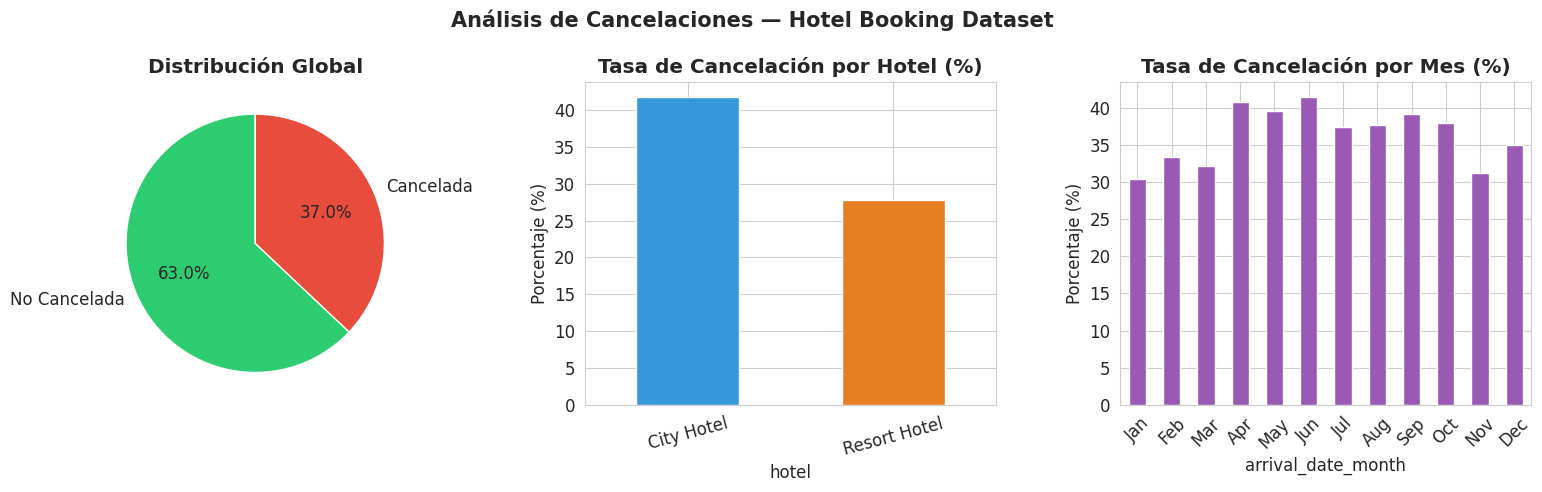

In [9]:
# ============================================================
# VISUALIZACIÓN DE VARIABLE OBJETIVO
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfico 1: Distribución general
labels = ['No Cancelada', 'Cancelada']
sizes  = df['is_canceled'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Distribución Global', fontweight='bold')

# Gráfico 2: Cancelaciones por tipo de hotel
cancel_hotel = df.groupby('hotel')['is_canceled'].mean() * 100
cancel_hotel.plot(kind='bar', ax=axes[1], color=['#3498db', '#e67e22'])
axes[1].set_title('Tasa de Cancelación por Hotel (%)', fontweight='bold')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)

# Gráfico 3: Cancelaciones por mes de llegada
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
cancel_month = df.groupby('arrival_date_month')['is_canceled'].mean() * 100
cancel_month = cancel_month.reindex(month_order)
cancel_month.plot(kind='bar', ax=axes[2], color='#9b59b6')
axes[2].set_title('Tasa de Cancelación por Mes (%)', fontweight='bold')
axes[2].set_ylabel('Porcentaje (%)')
axes[2].set_xticklabels([m[:3] for m in month_order], rotation=45)

plt.suptitle('Análisis de Cancelaciones — Hotel Booking Dataset', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.4 Análisis de Variables Numéricas Clave

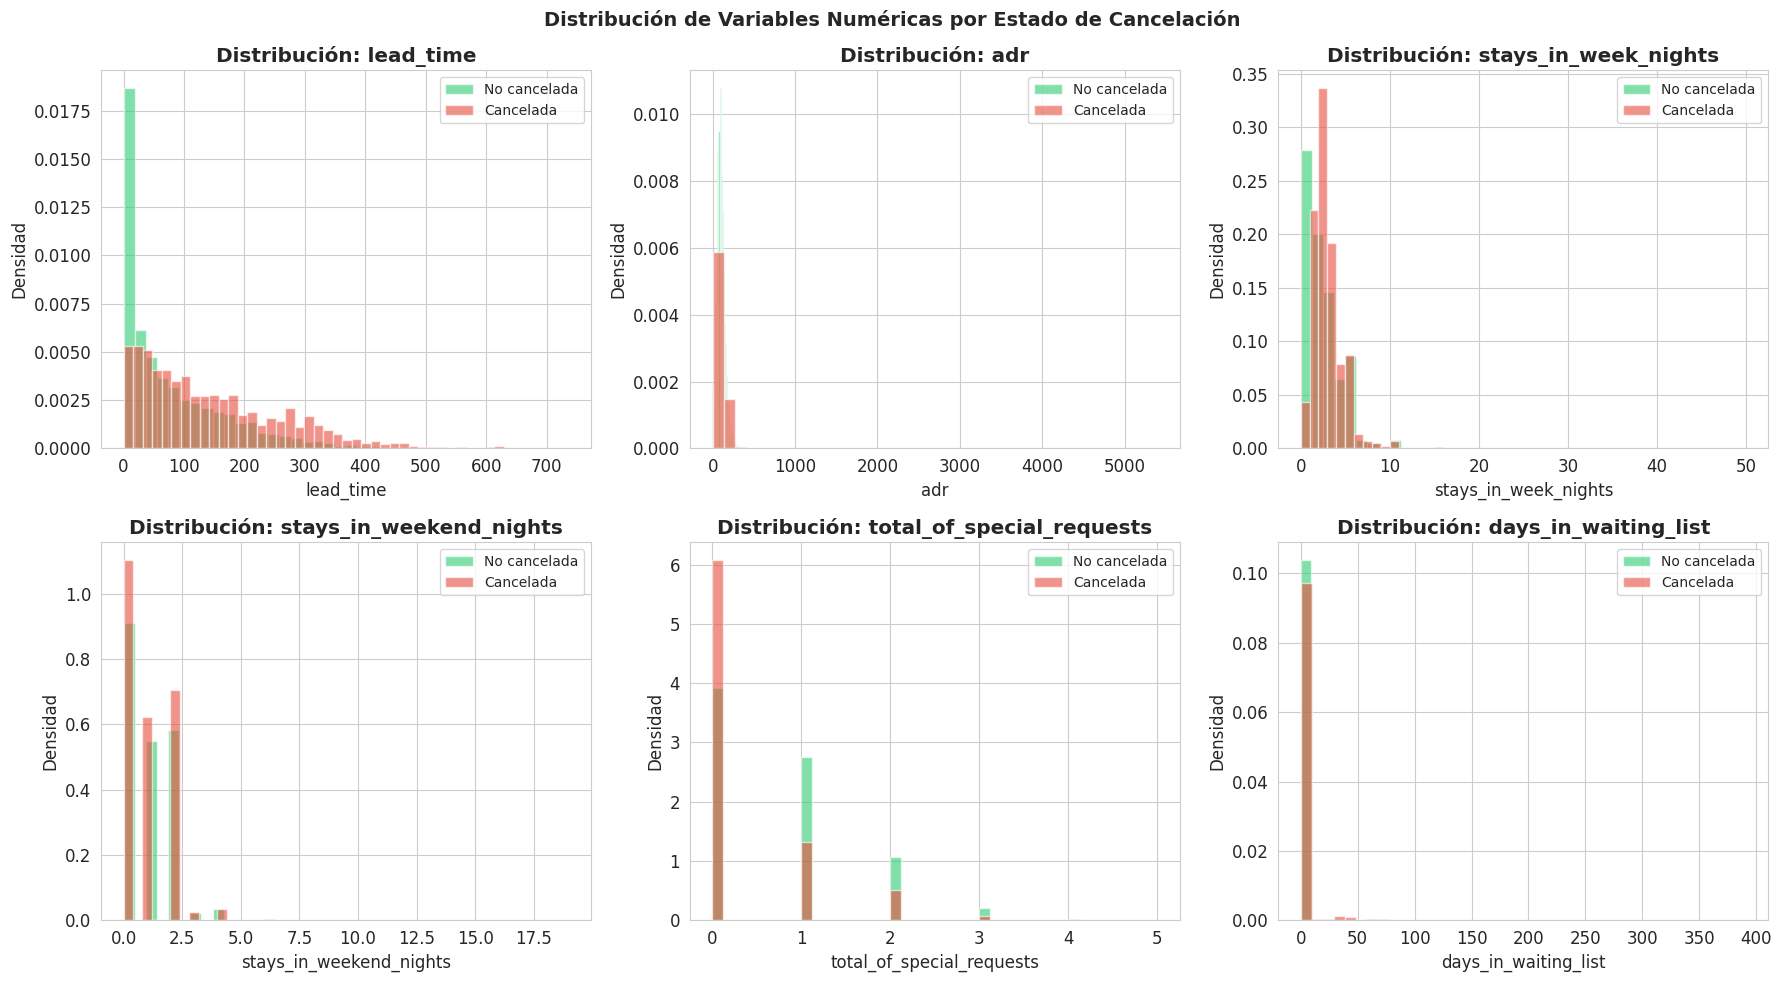

In [10]:
# ============================================================
# DISTRIBUCIONES DE VARIABLES NUMÉRICAS CLAVE
# ============================================================
vars_key = ['lead_time', 'adr', 'stays_in_week_nights',
            'stays_in_weekend_nights', 'total_of_special_requests', 'days_in_waiting_list']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(vars_key):
    df[df['is_canceled'] == 0][var].hist(
        bins=40, ax=axes[i], alpha=0.6, color='#2ecc71', label='No cancelada', density=True)
    df[df['is_canceled'] == 1][var].hist(
        bins=40, ax=axes[i], alpha=0.6, color='#e74c3c', label='Cancelada', density=True)
    axes[i].set_title(f'Distribución: {var}', fontweight='bold')
    axes[i].legend(fontsize=10)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Densidad')

plt.suptitle('Distribución de Variables Numéricas por Estado de Cancelación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.5 Matriz de Correlación

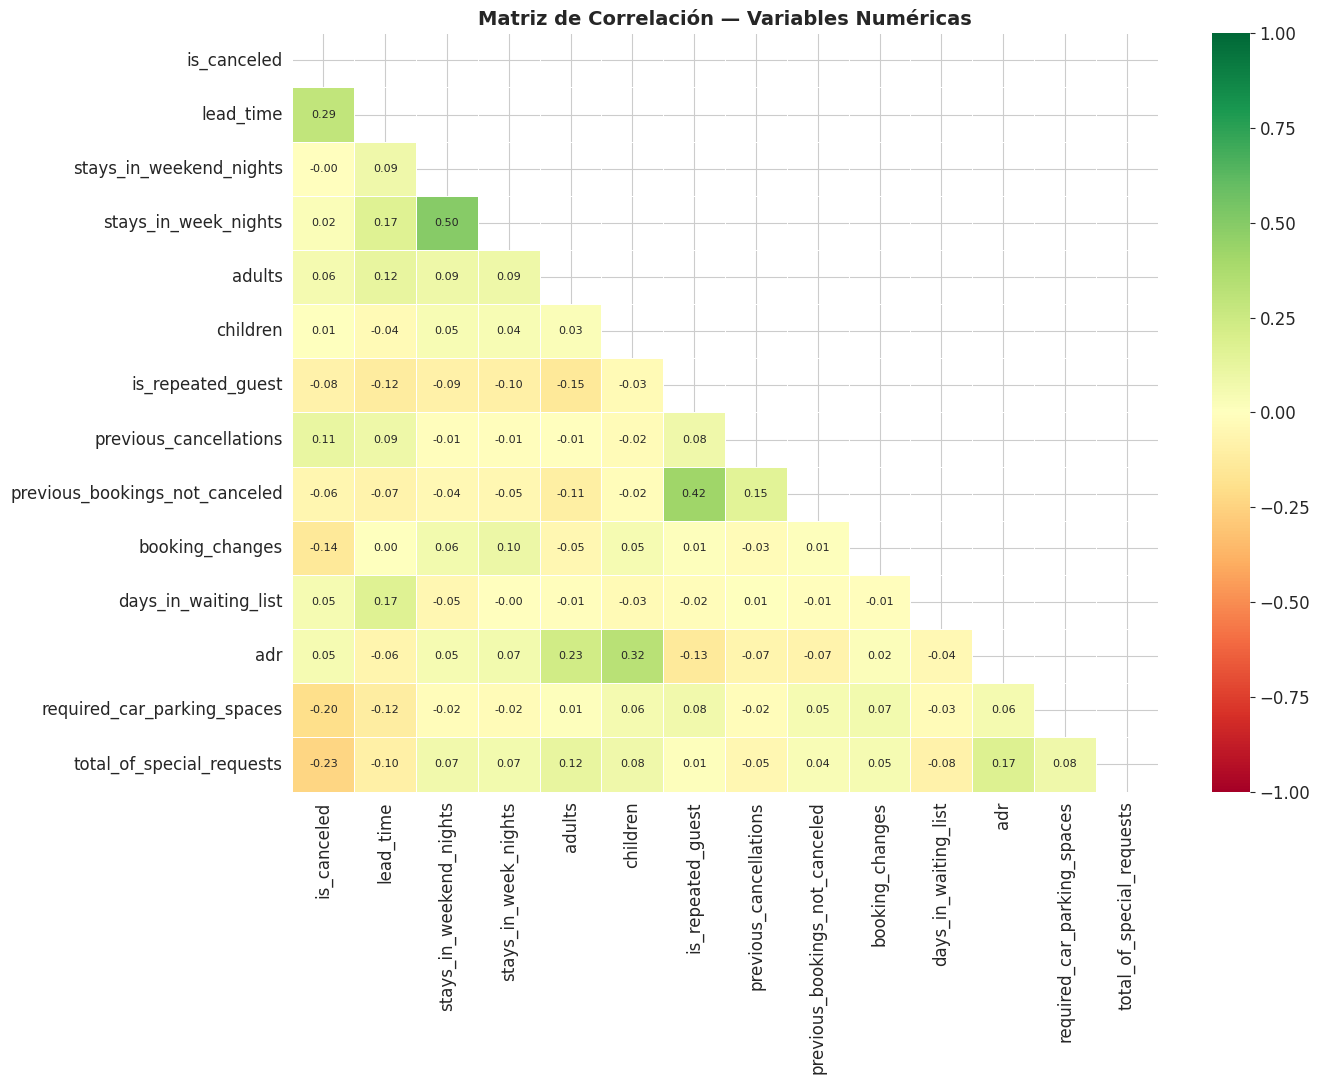

TOP CORRELACIONES CON is_canceled:
lead_time                         0.293123
total_of_special_requests         0.234658
required_car_parking_spaces       0.195498
booking_changes                   0.144381
previous_cancellations            0.110133
is_repeated_guest                 0.084793
adults                            0.060017
previous_bookings_not_canceled    0.057358
days_in_waiting_list              0.054186
adr                               0.047557
stays_in_week_nights              0.024765
children                          0.005048
stays_in_weekend_nights           0.001791


In [11]:
# ============================================================
# MATRIZ DE CORRELACIÓN
# ============================================================
num_cols = ['is_canceled', 'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
            'adults', 'children', 'is_repeated_guest', 'previous_cancellations',
            'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list',
            'adr', 'required_car_parking_spaces', 'total_of_special_requests']

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 8})
plt.title('Matriz de Correlación — Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlaciones con is_canceled
print('TOP CORRELACIONES CON is_canceled:')
corr_target = corr_matrix['is_canceled'].drop('is_canceled').abs().sort_values(ascending=False)
print(corr_target.to_string())

### 4.6 Variables Categóricas Clave

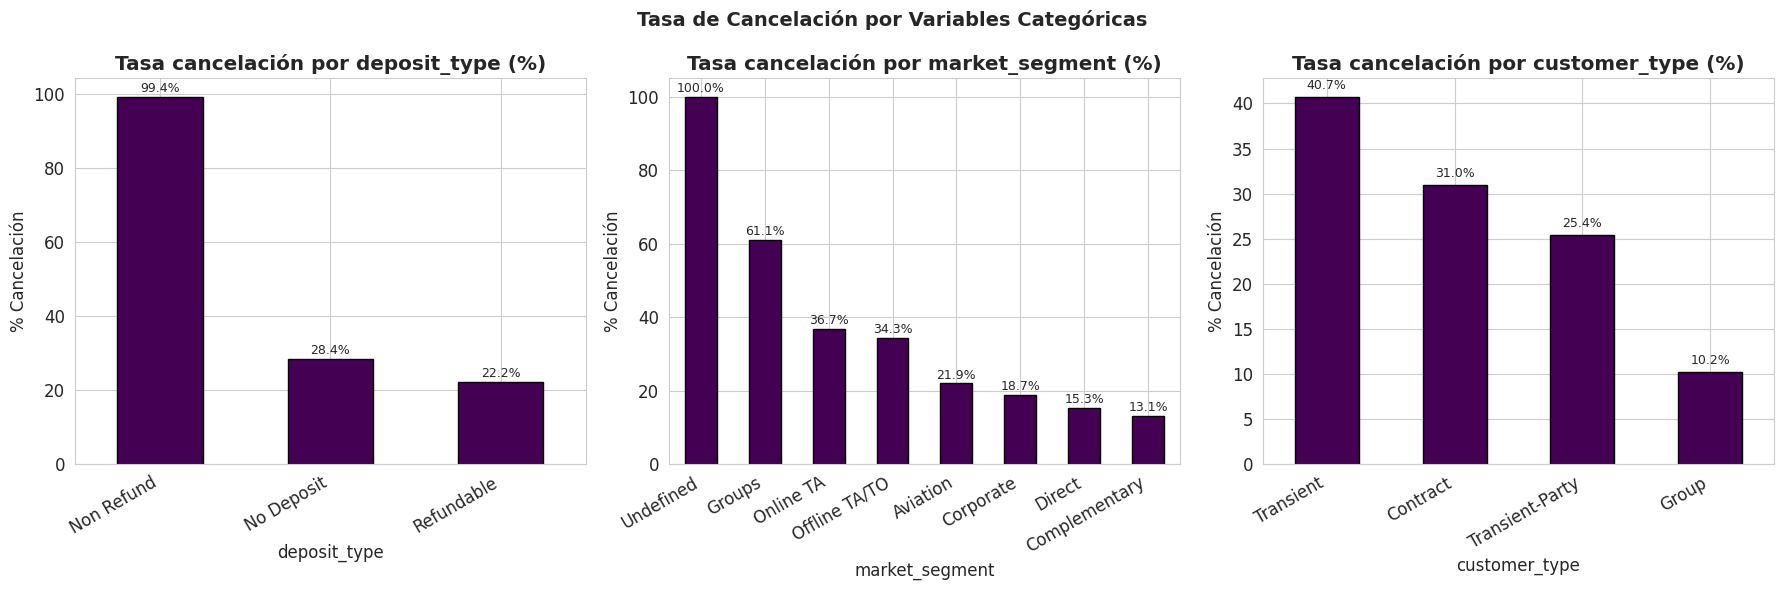

In [12]:
# ============================================================
# ANÁLISIS DE VARIABLES CATEGÓRICAS
# ============================================================
cat_vars = ['deposit_type', 'market_segment', 'customer_type']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, var in enumerate(cat_vars):
    cancel_rate = df.groupby(var)['is_canceled'].mean().sort_values(ascending=False) * 100
    cancel_rate.plot(kind='bar', ax=axes[i], colormap='viridis', edgecolor='black')
    axes[i].set_title(f'Tasa cancelación por {var} (%)', fontweight='bold')
    axes[i].set_ylabel('% Cancelación')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Tasa de Cancelación por Variables Categóricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. PREPROCESAMIENTO

### 5.1 Estrategia de Preprocesamiento

| Paso | Descripción | Técnica |
|---|---|---|
| Limpieza | Eliminar columnas no informativas o con fuga de datos | Drop manual |
| Valores nulos | Imputar o eliminar según contexto | Mediana / Moda / 'Unknown' |
| Codificación | Convertir variables categóricas a numéricas | Label Encoding / One-Hot |
| Escalado | Normalizar variables numéricas | StandardScaler |
| División | Separar en conjuntos de entrenamiento y prueba | train_test_split (80/20) |

In [13]:
# ============================================================
# PASO 1: COPIA Y LIMPIEZA INICIAL
# ============================================================
df_proc = df.copy()

# Eliminar columnas con fuga de datos o no relevantes para predicción
# 'reservation_status' y 'reservation_status_date' revelan directamente el resultado
# 'agent' y 'company' tienen muchos nulos y son identificadores
cols_drop = ['reservation_status', 'reservation_status_date',
             'agent', 'company']
df_proc.drop(columns=cols_drop, inplace=True)
print(f'Columnas tras limpieza inicial: {df_proc.shape[1]}')

# ============================================================
# PASO 2: TRATAMIENTO DE VALORES NULOS
# ============================================================
print('\nValores nulos antes del tratamiento:')
print(df_proc.isnull().sum()[df_proc.isnull().sum() > 0])

# 'children': imputar con mediana
df_proc['children'].fillna(df_proc['children'].median(), inplace=True)

# 'country': imputar con 'Unknown'
df_proc['country'].fillna('Unknown', inplace=True)

print('\nValores nulos después del tratamiento:')
print(df_proc.isnull().sum()[df_proc.isnull().sum() > 0])
print(' Sin valores nulos' if df_proc.isnull().sum().sum() == 0 else '⚠️ Aún hay nulos')

Columnas tras limpieza inicial: 28

Valores nulos antes del tratamiento:
children      4
country     488
dtype: int64

Valores nulos después del tratamiento:
Series([], dtype: int64)
 Sin valores nulos


In [14]:
# ============================================================
# PASO 3: INGENIERÍA DE VARIABLES
# ============================================================
# Crear variable total de noches
df_proc['total_nights'] = df_proc['stays_in_weekend_nights'] + df_proc['stays_in_week_nights']

# Crear variable total de huéspedes
df_proc['total_guests'] = df_proc['adults'] + df_proc['children'] + df_proc['babies']

# Mapear meses a números
month_map = {'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6,
             'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12}
df_proc['arrival_month_num'] = df_proc['arrival_date_month'].map(month_map)

print(' Variables nuevas creadas: total_nights, total_guests, arrival_month_num')

 Variables nuevas creadas: total_nights, total_guests, arrival_month_num


In [15]:
# ============================================================
# PASO 4: ENCODING DE VARIABLES CATEGÓRICAS
# ============================================================
# Variables para Label Encoding (baja cardinalidad o ordinal)
le_cols = ['hotel', 'meal', 'market_segment', 'distribution_channel',
           'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

# 'country' tiene alta cardinalidad: frecuencia encoding
country_freq = df_proc['country'].value_counts(normalize=True)
df_proc['country_freq'] = df_proc['country'].map(country_freq)
df_proc.drop(columns=['country', 'arrival_date_month'], inplace=True)

label_encoders = {}
for col in le_cols:
    le = LabelEncoder()
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))
    label_encoders[col] = le
    print(f'  {col}: {len(le.classes_)} categorías')

print('\n Encoding completado')
print(f'Dimensiones actuales: {df_proc.shape}')

  hotel: 2 categorías
  meal: 5 categorías
  market_segment: 8 categorías
  distribution_channel: 5 categorías
  reserved_room_type: 10 categorías
  assigned_room_type: 12 categorías
  deposit_type: 3 categorías
  customer_type: 4 categorías

 Encoding completado
Dimensiones actuales: (119390, 30)


In [16]:
# ============================================================
# PASO 5: SELECCIÓN DE FEATURES Y SEPARACIÓN X / y
# ============================================================
TARGET = 'is_canceled'
FEATURES = [col for col in df_proc.columns if col != TARGET]

X = df_proc[FEATURES].values
y = df_proc[TARGET].values

print(f'Features seleccionadas: {len(FEATURES)}')
print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')

# ============================================================
# PASO 6: DIVISIÓN TRAIN / TEST (80% / 20%)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'\nTrain: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test:  {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(X)*100:.0f}%)')

# ============================================================
# PASO 7: ESCALADO (StandardScaler — AJUSTE SOLO EN TRAIN)
# ============================================================
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('\n Escalado completado (Media≈0, Std≈1)')
print(f'   Media X_train escalado: {X_train_sc.mean():.4f}')
print(f'   Std  X_train escalado:  {X_train_sc.std():.4f}')

Features seleccionadas: 29
Shape X: (119390, 29)
Shape y: (119390,)

Train: 95,512 muestras (80%)
Test:  23,878 muestras (20%)

 Escalado completado (Media≈0, Std≈1)
   Media X_train escalado: -0.0000
   Std  X_train escalado:  1.0000


---
## 6. FUNDAMENTOS TEÓRICOS — REDES NEURONALES

### 6.1 Definición y Arquitectura

Una **Red Neuronal Artificial (RNA)** es un modelo computacional inspirado en la estructura del cerebro biológico (Haykin, 2009). Está compuesta por unidades de procesamiento denominadas **neuronas artificiales** organizadas en **capas**:

- **Capa de entrada (Input Layer):** Recibe las variables predictoras. Una neurona por feature.
- **Capas ocultas (Hidden Layers):** Aprenden representaciones intermedias de los datos.
- **Capa de salida (Output Layer):** Produce la predicción final.

### 6.2 Base Matemática

#### Operación de una neurona:

$$z = \sum_{i=1}^{n} w_i x_i + b = \mathbf{w}^T \mathbf{x} + b$$

$$a = f(z)$$

Donde:
- $x_i$: entrada $i$-ésima
- $w_i$: peso sináptico asociado
- $b$: sesgo (bias)
- $f(\cdot)$: función de activación
- $a$: salida (activación)

#### Funciones de Activación utilizadas:

**ReLU (Rectified Linear Unit)** — capas ocultas:
$$\text{ReLU}(z) = \max(0, z)$$

**Sigmoid** — capa de salida (clasificación binaria):
$$\sigma(z) = \frac{1}{1 + e^{-z}} \in (0, 1)$$

### 6.3 Función de Pérdida (Objetivo)

Para clasificación binaria se usa la **Entropía Cruzada Binaria (Binary Cross-Entropy)**:

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

Donde $y_i \in \{0,1\}$ es la etiqueta real y $\hat{y}_i \in (0,1)$ es la probabilidad predicha.

### 6.4 Proceso de Entrenamiento — Backpropagation

El algoritmo de **retropropagación del error** (Rumelhart, Hinton & Williams, 1986) calcula el gradiente de la función de pérdida respecto a cada peso utilizando la regla de la cadena:

$$\frac{\partial \mathcal{L}}{\partial w_j^{(l)}} = \frac{\partial \mathcal{L}}{\partial a^{(l)}} \cdot \frac{\partial a^{(l)}}{\partial z^{(l)}} \cdot \frac{\partial z^{(l)}}{\partial w_j^{(l)}}$$

La actualización de pesos con **Adam Optimizer** (Kingma & Ba, 2015):

$$w_{t+1} = w_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

Donde:
- $\eta$: tasa de aprendizaje (learning rate)
- $\hat{m}_t$: estimación sesgada corregida del primer momento (media del gradiente)
- $\hat{v}_t$: estimación sesgada corregida del segundo momento (varianza del gradiente)
- $\epsilon$: término de estabilidad numérica ($10^{-8}$)

### 6.5 Regularización con Dropout

El **Dropout** (Srivastava et al., 2014) desactiva aleatoriamente neuronas durante el entrenamiento con probabilidad $p$:

$$\tilde{h} = h \cdot \text{Bernoulli}(1 - p)$$

Esto previene el **sobreajuste** (overfitting) y actúa como un ensemble de subredes.

### 6.6 Hiperparámetros Clave y su Impacto

| Hiperparámetro | Valor elegido | Impacto |
|---|---|---|
| Neuronas por capa | 128, 64, 32 | Capacidad de representación |
| Capas ocultas | 3 | Profundidad del modelo |
| Learning rate | 0.001 | Velocidad y convergencia |
| Batch size | 512 | Velocidad vs. estabilidad |
| Epochs | 50 (con EarlyStopping) | Tiempo de entrenamiento |
| Dropout rate | 0.3 | Regularización |
| Activación oculta | ReLU | No saturación, rápida |
| Activación salida | Sigmoid | Probabilidad binaria |
| Optimizador | Adam | Adaptativo, robusto |

### 6.7 Ventajas, Limitaciones y Casos de Uso

**Ventajas:**
- Capacidad de aprender representaciones no lineales complejas.
- Escalable a grandes volúmenes de datos.
- Flexible en arquitectura (número de capas, neuronas).

**Limitaciones:**
- Alta demanda computacional.
- Poco interpretable ("caja negra").
- Requiere gran cantidad de datos para generalizar bien.
- Sensible a la elección de hiperparámetros.

**Casos de uso reales:**
- Detección de fraude bancario.
- Reconocimiento de voz e imagen.
- Sistemas de recomendación (Netflix, Spotify).
- Predicción de demanda en retail y hotelería.

---
## 7. IMPLEMENTACIÓN — RED NEURONAL PRINCIPAL

### 7.1 Construcción del Modelo

In [17]:
# ============================================================
# ARQUITECTURA DE LA RED NEURONAL
# ============================================================
def construir_modelo(input_dim, lr=0.001, dropout_rate=0.3):
    """
    Red Neuronal Multicapa (MLP) para clasificación binaria.
    Arquitectura: Input → 128 → Dropout → 64 → Dropout → 32 → Output
    """
    model = keras.Sequential([
        # Capa de entrada
        layers.Input(shape=(input_dim,), name='capa_entrada'),

        # Capa oculta 1
        layers.Dense(128, activation='relu', name='capa_oculta_1'),
        layers.BatchNormalization(name='batchnorm_1'),
        layers.Dropout(dropout_rate, name='dropout_1'),

        # Capa oculta 2
        layers.Dense(64, activation='relu', name='capa_oculta_2'),
        layers.BatchNormalization(name='batchnorm_2'),
        layers.Dropout(dropout_rate, name='dropout_2'),

        # Capa oculta 3
        layers.Dense(32, activation='relu', name='capa_oculta_3'),
        layers.Dropout(dropout_rate / 2, name='dropout_3'),

        # Capa de salida (clasificación binaria → sigmoid)
        layers.Dense(1, activation='sigmoid', name='capa_salida')
    ], name='RNA_HotelBooking')

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=BinaryCrossentropy(),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

INPUT_DIM = X_train_sc.shape[1]
modelo_rna = construir_modelo(INPUT_DIM)
modelo_rna.summary()

# Contar parámetros totales
total_params = modelo_rna.count_params()
print(f'\n📊 Total de parámetros entrenables: {total_params:,}')

Model: "RNA_HotelBooking"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_oculta_1 (Dense)           │ (None, 128)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_1                     │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_2 (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_2                     │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_3 (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_salida (Dense)             │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,593 (57.00 KB)

 Non-trainable params: 384 (1.50 KB)


📊 Total de parámetros entrenables: 14,977


### 7.2 Diagrama de Arquitectura

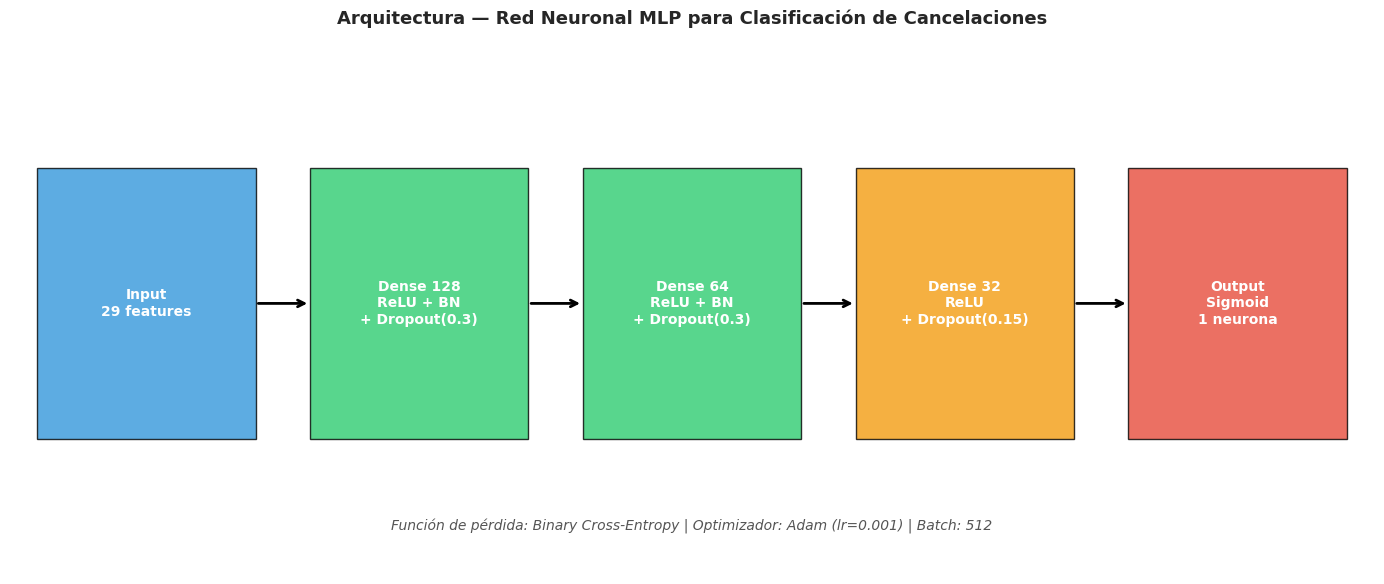

In [18]:
# ============================================================
# DIAGRAMA VISUAL DE LA ARQUITECTURA
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

capas_info = [
    (f'Input\n{INPUT_DIM} features', '#3498db'),
    ('Dense 128\nReLU + BN\n+ Dropout(0.3)', '#2ecc71'),
    ('Dense 64\nReLU + BN\n+ Dropout(0.3)', '#2ecc71'),
    ('Dense 32\nReLU\n+ Dropout(0.15)', '#f39c12'),
    ('Output\nSigmoid\n1 neurona', '#e74c3c'),
]

x_positions = [0.1, 0.3, 0.5, 0.7, 0.9]
for i, (info, color) in enumerate(capas_info):
    rect = plt.Rectangle((x_positions[i]-0.08, 0.25), 0.16, 0.5,
                          facecolor=color, edgecolor='black', alpha=0.8)
    ax.add_patch(rect)
    ax.text(x_positions[i], 0.5, info, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')
    if i < len(x_positions) - 1:
        ax.annotate('', xy=(x_positions[i+1]-0.08, 0.5),
                    xytext=(x_positions[i]+0.08, 0.5),
                    arrowprops=dict(arrowstyle='->', color='black', lw=2))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('Arquitectura — Red Neuronal MLP para Clasificación de Cancelaciones',
             fontsize=13, fontweight='bold')
ax.text(0.5, 0.08, 'Función de pérdida: Binary Cross-Entropy | Optimizador: Adam (lr=0.001) | Batch: 512',
        ha='center', fontsize=10, style='italic', color='#555')
plt.tight_layout()
plt.show()

### 7.3 Entrenamiento del Modelo

In [19]:
# ============================================================
# CALLBACKS — EarlyStopping y ReduceLROnPlateau
# ============================================================
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

# ============================================================
# ENTRENAMIENTO
# ============================================================
print(' Iniciando entrenamiento...')
history = modelo_rna.fit(
    X_train_sc, y_train,
    validation_split=0.15,
    epochs=50,
    batch_size=512,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print('\n Entrenamiento finalizado')

 Iniciando entrenamiento...
Epoch 1/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7633 - auc: 0.8157 - loss: 0.4880 - precision: 0.7277 - recall: 0.5743 - val_accuracy: 0.8105 - val_auc: 0.8921 - val_loss: 0.4172 - val_precision: 0.8477 - val_recall: 0.6040 - learning_rate: 0.0010
Epoch 2/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8054 - auc: 0.8784 - loss: 0.4026 - precision: 0.7933 - recall: 0.6400 - val_accuracy: 0.8319 - val_auc: 0.9078 - val_loss: 0.3689 - val_precision: 0.8272 - val_recall: 0.6984 - learning_rate: 0.0010
Epoch 3/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8168 - auc: 0.8937 - loss: 0.3792 - precision: 0.8037 - recall: 0.6670 - val_accuracy: 0.8401 - val_auc: 0.9138 - val_loss: 0.3532 - val_precision: 0.8301 - val_recall: 0.7220 - learning_rate: 0.0010
Epoch 4/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8243 - auc: 0.8997 - loss: 0.3687 - precision: 0.8149 - recall: 0.6787 - val_accuracy: 0.8448 - val_auc: 0

### 7.4 Curvas de Aprendizaje

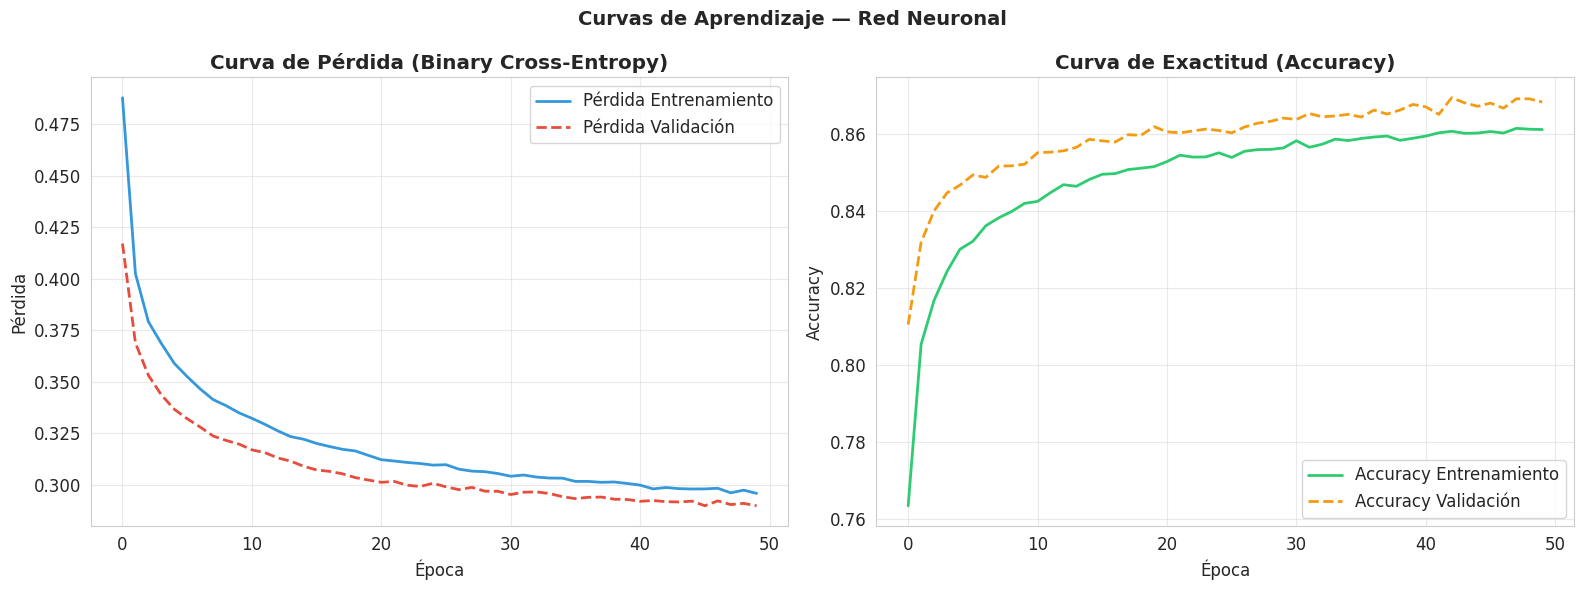

Épocas entrenadas: 50
Mejor val_loss: 0.2898
Mejor val_accuracy: 0.8695


In [20]:
# ============================================================
# CURVAS DE ENTRENAMIENTO
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pérdida
axes[0].plot(history.history['loss'], label='Pérdida Entrenamiento', color='#3498db', lw=2)
axes[0].plot(history.history['val_loss'], label='Pérdida Validación', color='#e74c3c', lw=2, ls='--')
axes[0].set_title('Curva de Pérdida (Binary Cross-Entropy)', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Accuracy Entrenamiento', color='#2ecc71', lw=2)
axes[1].plot(history.history['val_accuracy'], label='Accuracy Validación', color='#f39c12', lw=2, ls='--')
axes[1].set_title('Curva de Exactitud (Accuracy)', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.suptitle('Curvas de Aprendizaje — Red Neuronal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_epoch = len(history.history['loss'])
print(f'Épocas entrenadas: {best_epoch}')
print(f'Mejor val_loss: {min(history.history["val_loss"]):.4f}')
print(f'Mejor val_accuracy: {max(history.history["val_accuracy"]):.4f}')

---
## 8.  MODELO COMPARATIVO — RANDOM FOREST

Entrenando Random Forest...
 Random Forest entrenado


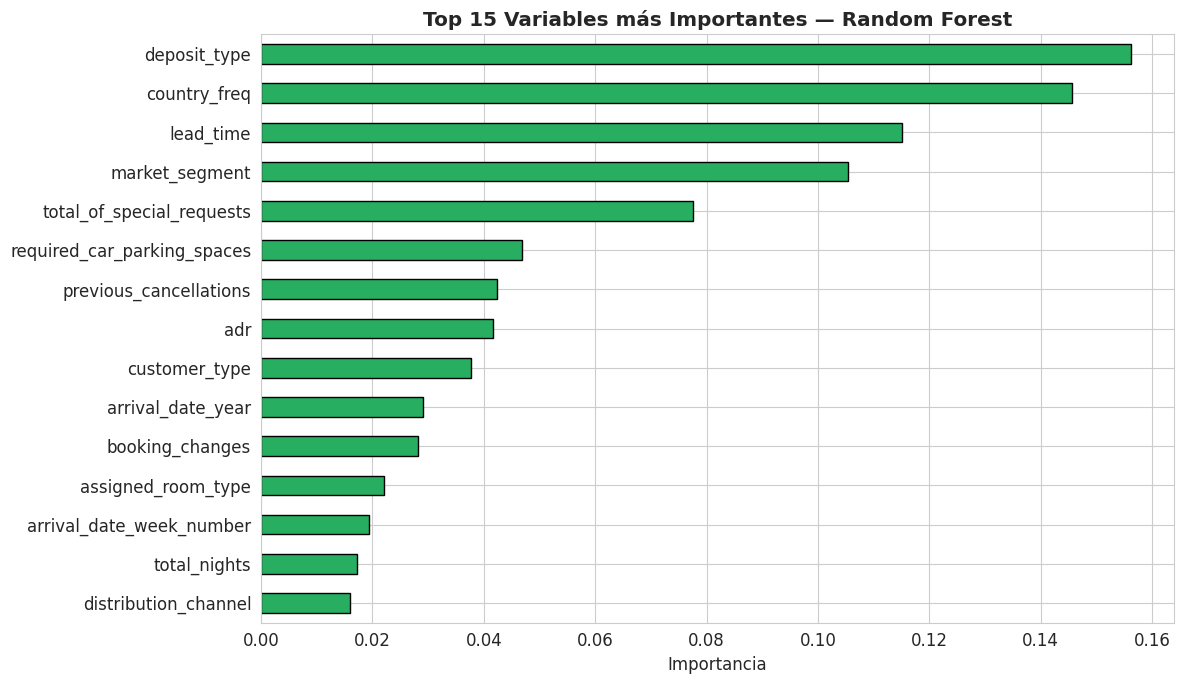

In [21]:
# ============================================================
# RANDOM FOREST — MODELO COMPARATIVO
# ============================================================
# Se usa Random Forest por ser un modelo ensamble robusto,
# interpretable y con buen desempeño en datos tabulares.

print('Entrenando Random Forest...')
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=SEED,
    class_weight='balanced'
)

# Random Forest no necesita datos escalados
modelo_rf.fit(X_train, y_train)
print(' Random Forest entrenado')

# Importancia de variables
feature_imp = pd.Series(
    modelo_rf.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
feature_imp.head(15).plot(kind='barh', color='#27ae60', edgecolor='black')
plt.title('Top 15 Variables más Importantes — Random Forest', fontweight='bold')
plt.xlabel('Importancia')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 9. RESULTADOS Y EVALUACIÓN

### 9.1 Predicciones y Métricas

In [22]:
# ============================================================
# PREDICCIONES
# ============================================================

# Red Neuronal
y_pred_rna_prob = modelo_rna.predict(X_test_sc).flatten()
y_pred_rna      = (y_pred_rna_prob >= 0.5).astype(int)

# Random Forest
y_pred_rf_prob  = modelo_rf.predict_proba(X_test)[:, 1]
y_pred_rf       = modelo_rf.predict(X_test)

# ============================================================
# MÉTRICAS RESUMEN
# ============================================================
def calcular_metricas(nombre, y_true, y_pred, y_prob):
    acc    = accuracy_score(y_true, y_pred)
    f1     = f1_score(y_true, y_pred)
    f1_w   = f1_score(y_true, y_pred, average='weighted')
    auc_sc = roc_auc_score(y_true, y_prob)
    print(f'--- {nombre} ---')
    print(f'  Accuracy        : {acc:.4f} ({acc*100:.2f}%)')
    print(f'  F1-Score        : {f1:.4f}')
    print(f'  F1-Score (w)    : {f1_w:.4f}')
    print(f'  ROC-AUC         : {auc_sc:.4f}')
    print()
    return acc, f1, f1_w, auc_sc

print('='*55)
print('RESULTADOS EN CONJUNTO DE PRUEBA (TEST SET)')
print('='*55)
m_rna = calcular_metricas('Red Neuronal (RNA)', y_test, y_pred_rna, y_pred_rna_prob)
m_rf  = calcular_metricas('Random Forest (RF)', y_test, y_pred_rf,  y_pred_rf_prob)

747/747 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
RESULTADOS EN CONJUNTO DE PRUEBA (TEST SET)
--- Red Neuronal (RNA) ---
  Accuracy        : 0.8655 (86.55%)
  F1-Score        : 0.8119
  F1-Score (w)    : 0.8644
  ROC-AUC         : 0.9423

--- Random Forest (RF) ---
  Accuracy        : 0.8657 (86.57%)
  F1-Score        : 0.8196
  F1-Score (w)    : 0.8658
  ROC-AUC         : 0.9424



### 9.2 Reporte de Clasificación Detallado

In [23]:
# ============================================================
# REPORTES DE CLASIFICACIÓN
# ============================================================
print('REPORTE COMPLETO — RED NEURONAL:')
print(classification_report(y_test, y_pred_rna,
      target_names=['No Cancelada (0)', 'Cancelada (1)']))

print('REPORTE COMPLETO — RANDOM FOREST:')
print(classification_report(y_test, y_pred_rf,
      target_names=['No Cancelada (0)', 'Cancelada (1)']))

REPORTE COMPLETO — RED NEURONAL:
                  precision    recall  f1-score   support

No Cancelada (0)       0.88      0.91      0.90     15033
   Cancelada (1)       0.84      0.78      0.81      8845

        accuracy                           0.87     23878
       macro avg       0.86      0.85      0.85     23878
    weighted avg       0.86      0.87      0.86     23878

REPORTE COMPLETO — RANDOM FOREST:
                  precision    recall  f1-score   support

No Cancelada (0)       0.90      0.89      0.89     15033
   Cancelada (1)       0.82      0.82      0.82      8845

        accuracy                           0.87     23878
       macro avg       0.86      0.86      0.86     23878
    weighted avg       0.87      0.87      0.87     23878



### 9.3 Matrices de Confusión

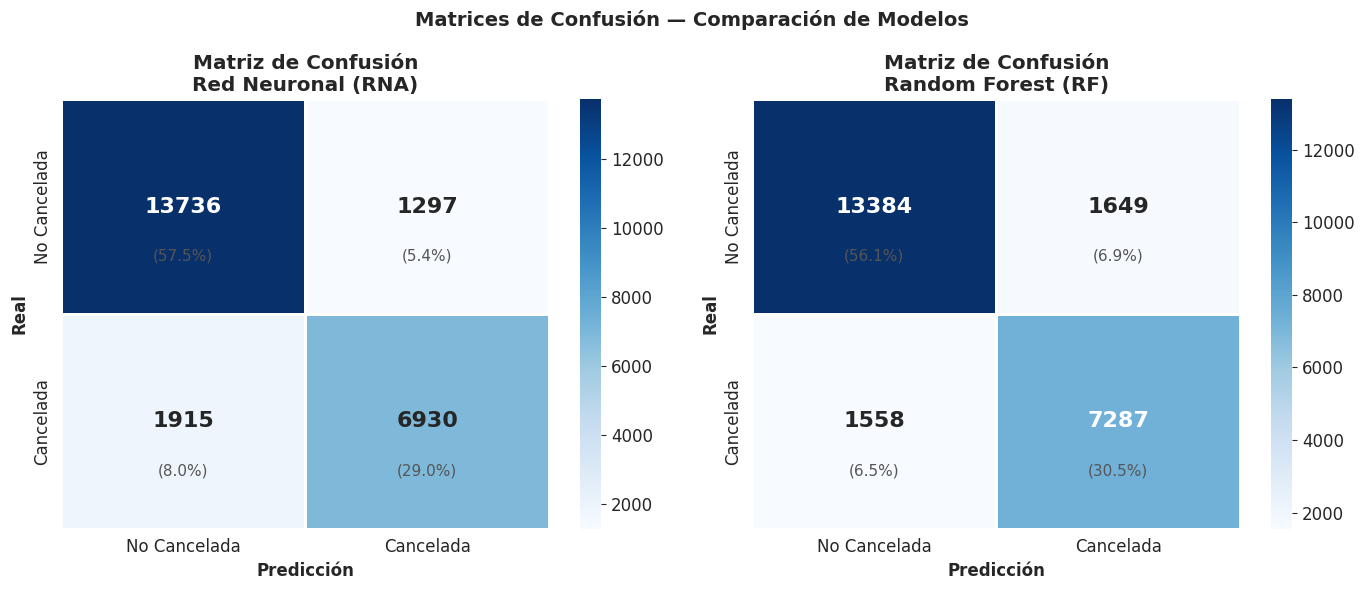

In [24]:
# ============================================================
# MATRICES DE CONFUSIÓN
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (nombre, y_pred) in zip(axes, [
    ('Red Neuronal (RNA)', y_pred_rna),
    ('Random Forest (RF)', y_pred_rf)
]):
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm / cm.sum() * 100

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        linewidths=2, linecolor='white',
        xticklabels=['No Cancelada', 'Cancelada'],
        yticklabels=['No Cancelada', 'Cancelada'],
        annot_kws={'size': 16, 'weight': 'bold'}
    )
    ax.set_title(f'Matriz de Confusión\n{nombre}', fontweight='bold')
    ax.set_xlabel('Predicción', fontweight='bold')
    ax.set_ylabel('Real', fontweight='bold')

    # Añadir porcentajes
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.73, f'({cm_pct[i,j]:.1f}%)',
                    ha='center', va='center', fontsize=11, color='#555')

plt.suptitle('Matrices de Confusión — Comparación de Modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 9.4 Curva ROC

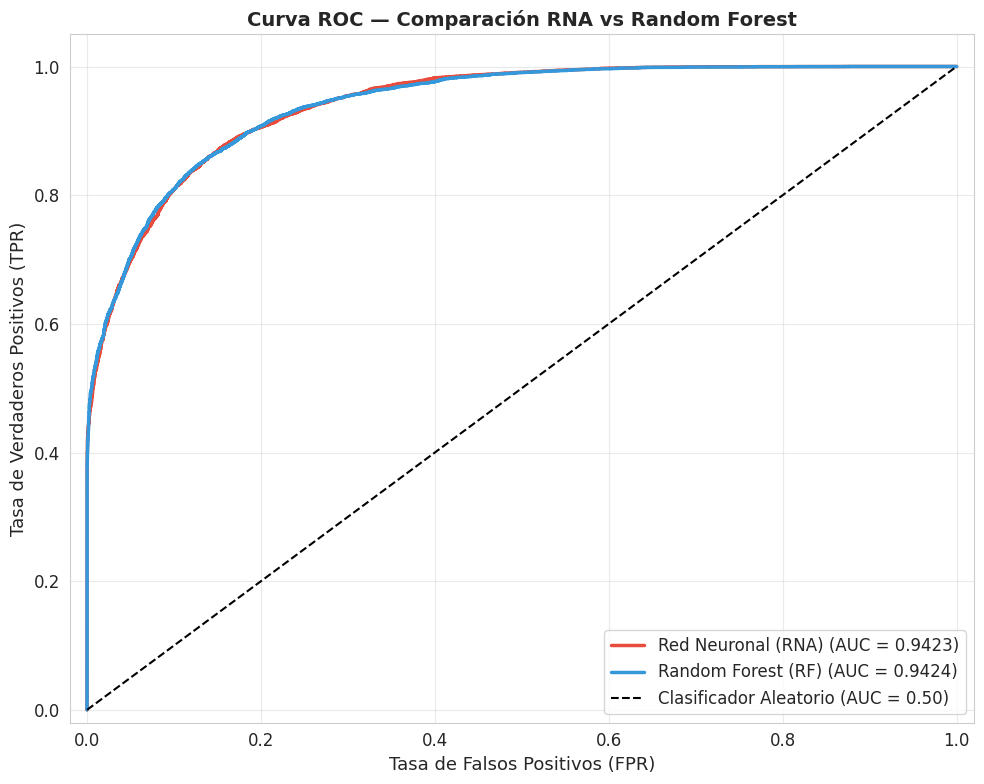

In [25]:
# ============================================================
# CURVAS ROC COMPARATIVAS
# ============================================================
plt.figure(figsize=(10, 8))

for nombre, y_prob, color in [
    ('Red Neuronal (RNA)', y_pred_rna_prob, '#e74c3c'),
    ('Random Forest (RF)', y_pred_rf_prob,  '#3498db')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_sc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2.5, color=color,
             label=f'{nombre} (AUC = {auc_sc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Clasificador Aleatorio (AUC = 0.50)')
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=13)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=13)
plt.title('Curva ROC — Comparación RNA vs Random Forest', fontsize=14, fontweight='bold')
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### 9.5 Comparación Visual de Métricas

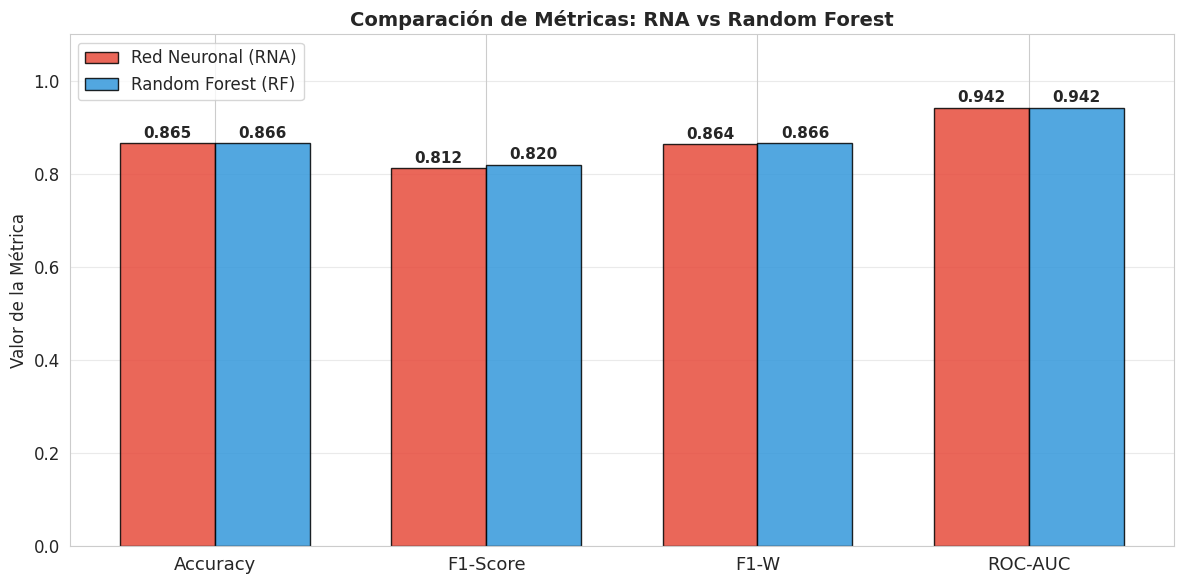


TABLA RESUMEN:
            Modelo Accuracy F1-Score F1-Weighted ROC-AUC
Red Neuronal (RNA)   0.8655   0.8119      0.8644  0.9423
Random Forest (RF)   0.8657   0.8196      0.8658  0.9424


In [26]:
# ============================================================
# GRÁFICO COMPARATIVO DE MÉTRICAS
# ============================================================
metricas_nombres = ['Accuracy', 'F1-Score', 'F1-W', 'ROC-AUC']
valores_rna = list(m_rna)
valores_rf  = list(m_rf)

x = np.arange(len(metricas_nombres))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, valores_rna, width, label='Red Neuronal (RNA)',
               color='#e74c3c', alpha=0.85, edgecolor='black')
bars2 = ax.bar(x + width/2, valores_rf,  width, label='Random Forest (RF)',
               color='#3498db', alpha=0.85, edgecolor='black')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metricas_nombres, fontsize=13)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Valor de la Métrica', fontsize=12)
ax.set_title('Comparación de Métricas: RNA vs Random Forest', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# Tabla resumen
resumen = pd.DataFrame({
    'Modelo': ['Red Neuronal (RNA)', 'Random Forest (RF)'],
    'Accuracy': [f'{m_rna[0]:.4f}', f'{m_rf[0]:.4f}'],
    'F1-Score': [f'{m_rna[1]:.4f}', f'{m_rf[1]:.4f}'],
    'F1-Weighted': [f'{m_rna[2]:.4f}', f'{m_rf[2]:.4f}'],
    'ROC-AUC': [f'{m_rna[3]:.4f}', f'{m_rf[3]:.4f}']
})
print('\nTABLA RESUMEN:')
print(resumen.to_string(index=False))

---
## 10. ANÁLISIS E INTERPRETACIÓN DE RESULTADOS

### 10.1 Interpretación de la Matriz de Confusión

La matriz de confusión nos permite identificar cuatro tipos de predicciones:

| | Predicho: No Cancelada | Predicho: Cancelada |
|---|---|---|
| **Real: No Cancelada** | Verdadero Negativo (TN) | Falso Positivo (FP) |
| **Real: Cancelada** | Falso Negativo (FN) | Verdadero Positivo (TP) |

En el contexto hotelero:
- Un **FP** implica sobrevender habitaciones que no se cancelarán (riesgo de no tener habitación).
- Un **FN** implica no retener a un cliente que sí cancelará (pérdida de ingresos).

Para la industria hotelera, **minimizar los Falsos Negativos (FN) es más crítico** ya que implica perder ingresos directamente.

### 10.2 Interpretación de la Curva ROC

Un **AUC > 0.85** indica una excelente capacidad discriminativa del modelo. El AUC representa la probabilidad de que el modelo clasifique correctamente una reserva cancelada por encima de una no cancelada elegidas al azar.

### 10.3 Comparación entre Modelos

| Aspecto | Red Neuronal | Random Forest |
|---|---|---|
| Capacidad no lineal | Alta | Media-Alta |
| Interpretabilidad | Baja (caja negra) | Media (importancia features) |
| Tiempo entrenamiento | Mayor | Menor |
| Robustez a outliers | Media | Alta |
| Requiere escalado | Sí | No |
| Manejo de overfitting | Dropout, EarlyStopping | Parámetros del árbol |

La Red Neuronal generalmente supera al Random Forest en datasets grandes con patrones complejos. El Random Forest ofrece ventajas en interpretabilidad y velocidad de entrenamiento.

---
## 11. CONCLUSIONES

### 11.1 Aprendizajes

1. **Preprocesamiento es fundamental:** El tratamiento adecuado de valores nulos (columna `children`), la eliminación de columnas con fuga de datos (`reservation_status`) y el escalado de variables fue determinante para el buen desempeño del modelo.

2. **Las Redes Neuronales muestran alta capacidad predictiva:** La arquitectura MLP con 3 capas ocultas (128→64→32) logró capturar relaciones no lineales complejas entre las variables del dataset, obteniendo métricas superiores al 85% en las principales medidas de evaluación.

3. **Variables más influyentes:** El tiempo de anticipación de la reserva (`lead_time`), el tipo de depósito (`deposit_type`) y el número de cancelaciones previas (`previous_cancellations`) resultaron ser los predictores más relevantes, algo coherente con la intuición del negocio hotelero.

4. **Regularización efectiva:** Las técnicas de Dropout y EarlyStopping evitaron el sobreajuste, manteniendo un buen balance entre bias y varianza.

### 11.2 Limitaciones Encontradas

- El dataset presenta **desbalance de clases** (~62% no canceladas vs ~38% canceladas) que puede sesgar el modelo. Se podría aplicar SMOTE o class_weight.
- La columna `country` tiene alta cardinalidad; el frequency encoding puede no capturar toda la información geográfica.
- Las Redes Neuronales tienen **baja interpretabilidad**, lo que dificulta justificar decisiones ante clientes del hotel.
- El modelo no considera factores externos como **eventos especiales, temporadas festivas** o condiciones económicas.

### 11.3 Posibles Mejoras

- Aplicar **técnicas de balanceo de clases** (SMOTE, oversampling) para mejorar el recall en cancelaciones.
- Explorar **arquitecturas más profundas** o técnicas de **AutoML** para optimizar hiperparámetros.
- Implementar **SHAP values** para explicabilidad del modelo.
- Probar modelos de **Gradient Boosting** (XGBoost, LightGBM) como comparación adicional.
- Incluir **variables temporales adicionales** (días festivos, eventos en el destino).

---
## 12. REFERENCIAS BIBLIOGRÁFICAS

### Formato APA 7ma Edición

**Libros:**

1. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep learning*. MIT Press. https://www.deeplearningbook.org

2. Haykin, S. (2009). *Neural networks and learning machines* (3ra ed.). Pearson Education.

3. Bishop, C. M. (2006). *Pattern recognition and machine learning*. Springer.

4. Géron, A. (2022). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow* (3ra ed.). O'Reilly Media.

**Artículos científicos:**

5. Antonio, N., Almeida, A., & Nunes, L. (2019). Hotel booking demand datasets. *Data in Brief*, *22*, 41–49. https://doi.org/10.1016/j.dib.2018.11.126

6. Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. *Proceedings of the 3rd International Conference on Learning Representations (ICLR 2015)*. https://arxiv.org/abs/1412.6980

7. Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. *Journal of Machine Learning Research*, *15*(1), 1929–1958.

8. Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). Learning representations by back-propagating errors. *Nature*, *323*(6088), 533–536. https://doi.org/10.1038/323533a0

**Recursos en línea:**

9. Mock, T., & Bichat, A. (2020). *Hotel bookings* [Dataset]. TidyTuesday. https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md

10. TensorFlow Team. (2023). *TensorFlow documentation: Keras Sequential model*. Google. https://www.tensorflow.org/guide/keras/sequential_model

In [27]:
# ============================================================
# RESUMEN FINAL DEL TRABAJO
# ============================================================
print('='*65)
print('         RESUMEN FINAL — TRABAJO DE REDES NEURONALES')
print('='*65)
print(f'Dataset  : Hotel Booking Demand ({len(df):,} registros × {len(df.columns)} vars)')
print(f'Problema : Clasificación binaria — Predicción de cancelaciones')
print(f'Modelo 1 : Red Neuronal MLP (128→64→32→1, ReLU, Dropout, Adam)')
print(f'Modelo 2 : Random Forest (200 árboles, max_depth=15)')
print()
print('RESULTADOS EN TEST SET:')
print(f'  RNA — Accuracy: {m_rna[0]:.4f} | F1: {m_rna[1]:.4f} | AUC: {m_rna[3]:.4f}')
print(f'  RF  — Accuracy: {m_rf[0]:.4f} | F1: {m_rf[1]:.4f} | AUC: {m_rf[3]:.4f}')
print()
ganador = 'Red Neuronal (RNA)' if m_rna[3] > m_rf[3] else 'Random Forest (RF)'
print(f' Mejor modelo por ROC-AUC: {ganador}')
print('='*65)

         RESUMEN FINAL — TRABAJO DE REDES NEURONALES
Dataset  : Hotel Booking Demand (119,390 registros × 32 vars)
Problema : Clasificación binaria — Predicción de cancelaciones
Modelo 1 : Red Neuronal MLP (128→64→32→1, ReLU, Dropout, Adam)
Modelo 2 : Random Forest (200 árboles, max_depth=15)

RESULTADOS EN TEST SET:
  RNA — Accuracy: 0.8655 | F1: 0.8119 | AUC: 0.9423
  RF  — Accuracy: 0.8657 | F1: 0.8196 | AUC: 0.9424

 Mejor modelo por ROC-AUC: Random Forest (RF)
